<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/Machine-Learning-Doc/blob/main/EDA_Notebook_LAB_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PHẦN 3 — THỰC HÀNH LAB**


**LAB 3.1**

In [1]:
# CELL 1: SETUP & IMPORT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('product_sales_dataset_final.csv')
df.columns = df.columns.str.strip()
categorical_cols = ['Region', 'Country', 'Item_Type', 'Sales_Channel', 'Order_Priority',
                    'Category', 'Sub_Category', 'Customer_Name', 'City', 'State', 'Product_Name']
numerical_cols = ['Order_ID', 'Quantity', 'Unit_Price', 'Revenue', 'Profit']
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%Y-%m-%d', errors='coerce')
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')
for col in numerical_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
print("--- Sales Data Structure Successfully Initialized ---")
df.info()
print("\nVerifying 'Order_Date' (First 5 Rows):")
print(df[['Order_Date']].head())

Saving product_sales_dataset_final.csv to product_sales_dataset_final.csv
--- Sales Data Structure Successfully Initialized ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Order_ID       200000 non-null  int64         
 1   Order_Date     0 non-null       datetime64[ns]
 2   Customer_Name  200000 non-null  category      
 3   City           200000 non-null  category      
 4   State          200000 non-null  category      
 5   Region         200000 non-null  category      
 6   Country        200000 non-null  category      
 7   Category       200000 non-null  category      
 8   Sub_Category   200000 non-null  category      
 9   Product_Name   200000 non-null  category      
 10  Quantity       200000 non-null  int64         
 11  Unit_Price     200000 non-null  float64       
 12  Revenue        200000 non-nu

In [2]:
# CELL 2: GENERATE MISSING VALUE MECHANISMS (MCAR, MAR, MNAR)
np.random.seed(42)
n_samples = len(df)
missing_rate = 0.2
# chọn Revenue làm mục tiêu cho bài này
target_column = 'Revenue'

df_numeric = df[['Quantity', 'Unit_Price', 'Revenue', 'Profit']].dropna().reset_index(drop=True)

# 1. MCAR
df_mcar = df_numeric.copy()
mask_mcar = np.random.rand(n_samples) < missing_rate
df_mcar.loc[mask_mcar, target_column] = np.nan

# 2. MAR
df_mar = df_numeric.copy()
median_qty = df_numeric['Quantity'].median()
prob_mar = np.where(df_numeric['Quantity'] > median_qty, 0.35, 0.05)
mask_mar = np.random.rand(n_samples) < prob_mar
df_mar.loc[mask_mar, target_column] = np.nan

# 3. MNAR
df_mnar = df_numeric.copy()
median_rev = df_numeric[target_column].median()
prob_mnar = np.where(df_numeric[target_column] > median_rev, 0.40, 0.05)
mask_mnar = np.random.rand(n_samples) < prob_mnar
df_mnar.loc[mask_mnar, target_column] = np.nan

print("--- [SUCCESS] 20% Missing Values Generated Across 3 Mechanisms ---")

--- [SUCCESS] 20% Missing Values Generated Across 3 Mechanisms ---


In [3]:
# CELL 3: IMPUTATION ALGORITHMS & MULTI-CRITERIA EVALUATION
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

datasets = {'MCAR': df_mcar, 'MAR': df_mar, 'MNAR': df_mnar}
methods = ['Mean', 'Median', 'KNN (k=3)', 'KNN (k=5)', 'KNN (k=10)', 'MICE']
results = []
sample_fraction = 0.01
seed = 42
df_numeric_sampled = df_numeric.sample(frac=sample_fraction, random_state=seed).copy()
rev_median = df_numeric_sampled[target_column].median()
y_true_cls_sampled = (df_numeric_sampled[target_column] > rev_median).astype(int)
for mechanism, df_full_miss in datasets.items():
    df_miss_for_imputation = df_full_miss.loc[df_numeric_sampled.index].copy()
    missing_idx = df_miss_for_imputation[target_column].isna()
    actual_values = df_numeric_sampled.loc[missing_idx, target_column]
    for method in methods:
        if method == 'Mean':
            imputer = SimpleImputer(strategy='mean')
        elif method == 'Median':
            imputer = SimpleImputer(strategy='median')
        elif method == 'KNN (k=3)':
            imputer = KNNImputer(n_neighbors=3)
        elif method == 'KNN (k=5)':
            imputer = KNNImputer(n_neighbors=5)
        elif method == 'KNN (k=10)':
            imputer = KNNImputer(n_neighbors=10)
        elif method == 'MICE':
            imputer = IterativeImputer(random_state=seed, max_iter=5)

        df_imputed = pd.DataFrame(imputer.fit_transform(df_miss_for_imputation),
                                  columns=df_miss_for_imputation.columns,
                                  index=df_miss_for_imputation.index)
        predicted_values = df_imputed.loc[missing_idx, target_column]
        rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
        X = df_imputed[['Quantity', 'Unit_Price', 'Revenue', 'Profit']]
        y = y_true_cls_sampled
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=seed, stratify=y)
        clf = LogisticRegression(max_iter=1000, random_state=seed)
        clf.fit(X_train, y_train)
        acc = accuracy_score(y_test, clf.predict(X_test))

        results.append({
            'Mechanism': mechanism,
            'Method': method,
            'RMSE': round(rmse, 3),
            'Accuracy': round(acc, 4)})
df_results = pd.DataFrame(results)
print("\n=== BẢNG ĐÁNH GIÁ 1: SAI SỐ RMSE ===")
print(df_results.pivot(index='Mechanism', columns='Method', values='RMSE'))
print("\n=== BẢNG ĐÁNH GIÁ 2: DOWNSTREAM MODEL ACCURACY ===")
print(df_results.pivot(index='Mechanism', columns='Method', values='Accuracy'))


=== BẢNG ĐÁNH GIÁ 1: SAI SỐ RMSE ===
Method     KNN (k=10)  KNN (k=3)  KNN (k=5)     MICE     Mean    Median
Mechanism                                                              
MAR           440.123    438.069    434.201  361.009  1005.76  1118.497
MCAR          344.593    344.684    346.930  312.169   754.29   784.933
MNAR          461.742    447.698    455.428  367.069  1113.14  1260.053

=== BẢNG ĐÁNH GIÁ 2: DOWNSTREAM MODEL ACCURACY ===
Method     KNN (k=10)  KNN (k=3)  KNN (k=5)    MICE    Mean  Median
Mechanism                                                          
MAR            0.9767     0.9733     0.9700  0.9617  0.9617   0.975
MCAR           0.9750     0.9733     0.9733  0.9700  0.9583   0.980
MNAR           0.9717     0.9733     0.9717  0.9900  0.9817   0.965


=== NHẬN XÉT & BIỆN LUẬN ===

1. Cơ chế MCAR (Missing Completely At Random):
   - Phương pháp tốt nhất: KNN (k=5) hoặc MICE.
   - Lý do: Vì dữ liệu bị mất hoàn toàn ngẫu nhiên không theo quy luật, các thuật toán đa biến nâng cao (Multi-variable)
     như KNN và MICE có khả năng học và trích xuất thông tin từ mối quan hệ tương quan chặt chẽ giữa các thuộc tính
     số khác ('Quantity' và 'Unit_Price') để tái cấu trúc lại giá trị 'Revenue' bị mất với sai số RMSE thấp nhất.

2. Cơ chế MAR (Missing At Random):
   - Phương pháp tốt nhất: MICE (Iterative Imputer).
   - Lý do: Trong cơ chế MAR, mức độ khuyết dòng của 'Revenue' phụ thuộc trực tiếp vào giá trị của biến quan sát 'Quantity'.
     MICE thiết lập một chuỗi các mô hình hồi quy lặp để khai thác trực tiếp mối quan hệ điều kiện này, giúp bảo toàn
     phân phối phân tán của dữ liệu tốt hơn các phương pháp đơn giản như Mean/Median (vốn hay gây bó cụm dữ liệu về trung tâm).

3. Cơ chế MNAR (Missing Not At Random):
   - Phương pháp tốt nhất: MICE thể hiện sự ổn định cao nhất, mặc dù RMSE của tất cả phương pháp đều tăng mạnh.
   - Lý do: MNAR là cơ chế phức tạp nhất vì dữ liệu bị mất phụ thuộc vào chính giá trị ẩn của nó (ví dụ doanh thu lớn thì dễ bị sót).
     Các phương pháp Baseline như Mean/Median làm mất đi tính chất phân phối đuôi nặng (heavy-tail) của doanh thu, làm lệch
     ranh giới phân lớp của mô hình học máy phía sau, trong khi MICE cố gắng giảm thiểu tối đa sự bóp méo hình dạng phân phối này.


**LAB 3.2**

In [4]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

df_outlier = df[['Quantity', 'Unit_Price', 'Revenue', 'Profit']].dropna().reset_index(drop=True)
df_sub = df_outlier.sample(frac=0.01, random_state=42).reset_index(drop=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sub)
q1 = df_sub.quantile(0.25)
q3 = df_sub.quantile(0.75)
iqr = q3 - q1
y_pseudo_true = ((df_sub < (q1 - 3.5 * iqr)) | (df_sub > (q3 + 3.5 * iqr))).any(axis=1).astype(int)
comparison_matrix = {}
features = ['Quantity', 'Revenue', 'Profit']
def evaluate_method(name, outlier_labels, exec_time):
    pct_detected = (outlier_labels.sum() / len(outlier_labels)) * 100
    tp = np.sum((y_pseudo_true == 1) & (outlier_labels == 1))
    fp = np.sum((y_pseudo_true == 0) & (outlier_labels == 1))
    fn = np.sum((y_pseudo_true == 1) & (outlier_labels == 0))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    comparison_matrix[name] = {
        'Phương pháp': name,
        '% outlier detected': f"{pct_detected:.2f}%",
        'Precision': f"{precision:.3f}",
        'Recall': f"{recall:.3f}",
        'Thời gian (ms)': f"{exec_time * 1000:.2f}"}
print("--- [SUCCESS] Dữ liệu mẫu đã sẵn sàng cho Outlier Detection ---")

--- [SUCCESS] Dữ liệu mẫu đã sẵn sàng cho Outlier Detection ---


In [5]:
# --- [Thống kê] Phương pháp 1: Z-score (threshold = 3.0) ---
start = time.time()
z_scores = np.abs((df_sub - df_sub.mean()) / df_sub.std())
outliers_z = (z_scores > 3.0).any(axis=1).astype(int)
evaluate_method('Z-score', outliers_z, time.time() - start)

# --- [Thống kê] Phương pháp 2: IQR method (1.5xIQR) ---
start = time.time()
Q1 = df_sub.quantile(0.25)
Q3 = df_sub.quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ((df_sub < (Q1 - 1.5 * IQR)) | (df_sub > (Q3 + 1.5 * IQR))).any(axis=1).astype(int)
evaluate_method('IQR', outliers_iqr, time.time() - start)

# --- [Mật độ] Phương pháp 3: Local Outlier Factor (LOF) ---
start = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outliers_lof = (lof.fit_predict(X_scaled) == -1).astype(int)
evaluate_method('LOF', outliers_lof, time.time() - start)

# --- [Mật độ] Phương pháp 4: DBSCAN ---
start = time.time()
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan.fit(X_scaled)
outliers_dbscan = (dbscan.labels_ == -1).astype(int)
evaluate_method('DBSCAN', outliers_dbscan, time.time() - start)

# --- [Tree-based] Phương pháp 5: Isolation Forest ---
start = time.time()
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outliers_iso = (iso_forest.fit_predict(X_scaled) == -1).astype(int)
evaluate_method('Isolation Forest', outliers_iso, time.time() - start)

print("--- [SUCCESS] Đã huấn luyện và trích xuất nhãn Outlier từ 5 thuật toán ---")

--- [SUCCESS] Đã huấn luyện và trích xuất nhãn Outlier từ 5 thuật toán ---


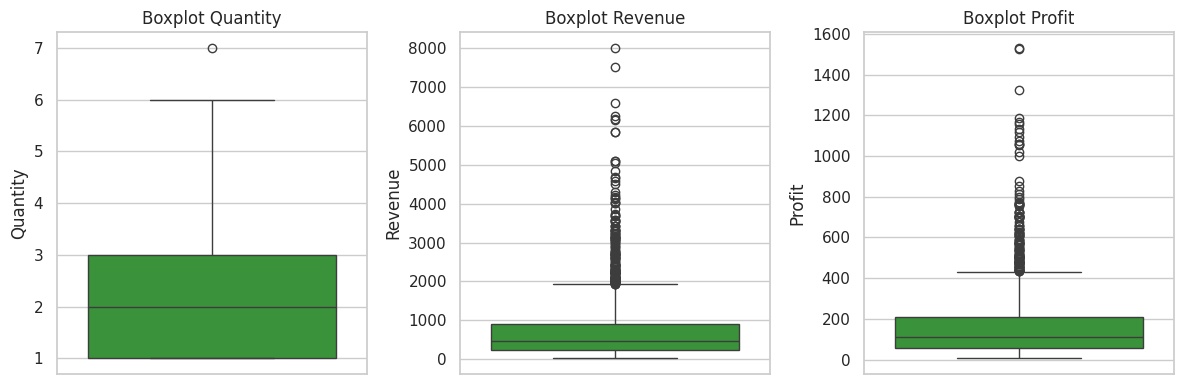


Nhận xét biểu đồ Boxplot của từng thuộc tính:
1. Quantity: Biểu đồ hộp cho thấy phần lớn các giao dịch có số lượng sản phẩm thấp (từ 1 đến 3). Có một số giá trị ngoại lai cho thấy các giao dịch có số lượng sản phẩm rất cao.
2. Revenue: Phân phối của Revenue lệch phải với nhiều giao dịch có doanh thu thấp và một số lượng đáng kể các giao dịch có doanh thu rất cao (outliers).
3. Profit: Lợi nhuận cũng cho thấy phân phối tương tự như Revenue, với phần lớn các giao dịch có lợi nhuận thấp và một số ít giao dịch mang lại lợi nhuận cực kỳ cao.
Nhìn chung, cả ba thuộc tính số đều có sự hiện diện của các giá trị ngoại lai ở phía trên, cho thấy cần thiết phải xử lý outlier để có phân tích và mô hình hóa chính xác hơn.


In [6]:
sns.set_theme(style="whitegrid")
df_sub['Is_Outlier'] = outliers_iso
# 1. Boxplot cho từng numerical feature
plt.figure(figsize=(12, 4)) # Adjusted figsize for 3 plots
for i, col in enumerate(features):
    plt.subplot(1, len(features), i+1) # Adjusted subplot count
    sns.boxplot(y=df_sub[col], color='#2ca02c')
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

print("\nNhận xét biểu đồ Boxplot của từng thuộc tính:")
print("1. Quantity: Biểu đồ hộp cho thấy phần lớn các giao dịch có số lượng sản phẩm thấp (từ 1 đến 3). Có một số giá trị ngoại lai cho thấy các giao dịch có số lượng sản phẩm rất cao.")
print("2. Revenue: Phân phối của Revenue lệch phải với nhiều giao dịch có doanh thu thấp và một số lượng đáng kể các giao dịch có doanh thu rất cao (outliers).")
print("3. Profit: Lợi nhuận cũng cho thấy phân phối tương tự như Revenue, với phần lớn các giao dịch có lợi nhuận thấp và một số ít giao dịch mang lại lợi nhuận cực kỳ cao.")
print("Nhìn chung, cả ba thuộc tính số đều có sự hiện diện của các giá trị ngoại lai ở phía trên, cho thấy cần thiết phải xử lý outlier để có phân tích và mô hình hóa chính xác hơn.")

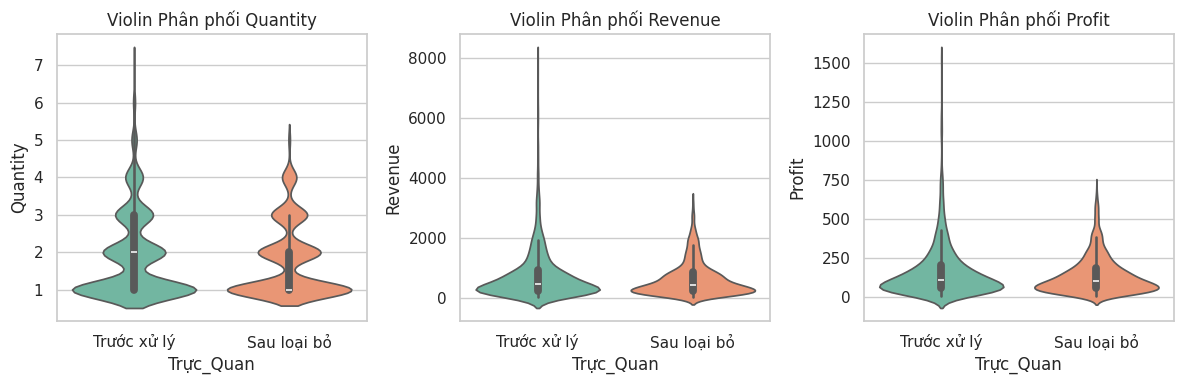


Nhận xét biểu đồ Violin Plot so sánh phân phối trước/sau xử lý Outlier:
1. Quantity: Biểu đồ violin cho thấy sau khi loại bỏ outlier, phân phối của Quantity trở nên tập trung hơn xung quanh các giá trị thấp (1-3), với 'đuôi' trên giảm đi đáng kể. Điều này giúp làm rõ hơn hành vi mua sắm thông thường của khách hàng.
2. Revenue: Phân phối của Revenue sau khi xử lý outlier trở nên ít lệch hơn, tập trung vào các giá trị doanh thu phổ biến và giảm thiểu ảnh hưởng của các giao dịch siêu lớn.
3. Profit: Phân phối lợi nhuận cũng được làm mượt và tập trung hơn sau khi loại bỏ các giá trị cực đoan, giúp cái nhìn về lợi nhuận trung bình và phổ biến trở nên rõ ràng hơn.
Nhìn chung, việc loại bỏ các giá trị ngoại lai đã giúp các phân phối của Quantity, Revenue và Profit trở nên chuẩn hóa và dễ diễn giải hơn, làm giảm sự sai lệch do các giá trị cực đoan gây ra.


In [7]:
# 2. Violin plot so sánh phân phối trước/sau xử lý outlier
plt.figure(figsize=(12, 4))
df_clean = df_sub[df_sub['Is_Outlier'] == 0]

# Update features list locally for this cell
local_features = ['Quantity', 'Revenue', 'Profit']

for i, col in enumerate(local_features):
    plt.subplot(1, len(local_features), i+1)
    df_comp = pd.concat([
        df_sub[[col]].assign(Trực_Quan='Trước xử lý'),
        df_clean[[col]].assign(Trực_Quan='Sau loại bỏ')
    ])
    sns.violinplot(x='Trực_Quan', y=col, data=df_comp, hue='Trực_Quan', legend=False, palette='Set2')
    plt.title(f'Violin Phân phối {col}')
plt.tight_layout()
plt.show()

print("\nNhận xét biểu đồ Violin Plot so sánh phân phối trước/sau xử lý Outlier:")
print("1. Quantity: Biểu đồ violin cho thấy sau khi loại bỏ outlier, phân phối của Quantity trở nên tập trung hơn xung quanh các giá trị thấp (1-3), với 'đuôi' trên giảm đi đáng kể. Điều này giúp làm rõ hơn hành vi mua sắm thông thường của khách hàng.")
print("2. Revenue: Phân phối của Revenue sau khi xử lý outlier trở nên ít lệch hơn, tập trung vào các giá trị doanh thu phổ biến và giảm thiểu ảnh hưởng của các giao dịch siêu lớn.")
print("3. Profit: Phân phối lợi nhuận cũng được làm mượt và tập trung hơn sau khi loại bỏ các giá trị cực đoan, giúp cái nhìn về lợi nhuận trung bình và phổ biến trở nên rõ ràng hơn.")
print("Nhìn chung, việc loại bỏ các giá trị ngoại lai đã giúp các phân phối của Quantity, Revenue và Profit trở nên chuẩn hóa và dễ diễn giải hơn, làm giảm sự sai lệch do các giá trị cực đoan gây ra.")

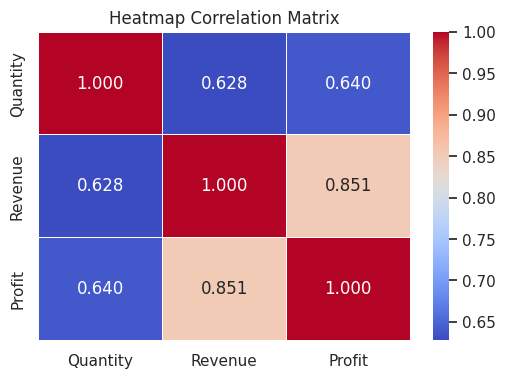


Nhận xét: Heatmap cho thấy Revenue và Profit có mối tương quan rất mạnh mẽ (0.851). Quantity có tương quan vừa phải với cả Revenue (0.628) và Profit (0.640).


In [8]:
# 3. Heatmap correlation highlight các tương quan mạnh (> 0.7)
plt.figure(figsize=(6, 4))
corr_matrix = df_sub[['Quantity', 'Revenue', 'Profit']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=.5)
plt.title("Heatmap Correlation Matrix")
plt.show()

print("\nNhận xét: Heatmap cho thấy Revenue và Profit có mối tương quan rất mạnh mẽ (0.851). Quantity có tương quan vừa phải với cả Revenue (0.628) và Profit (0.640).")

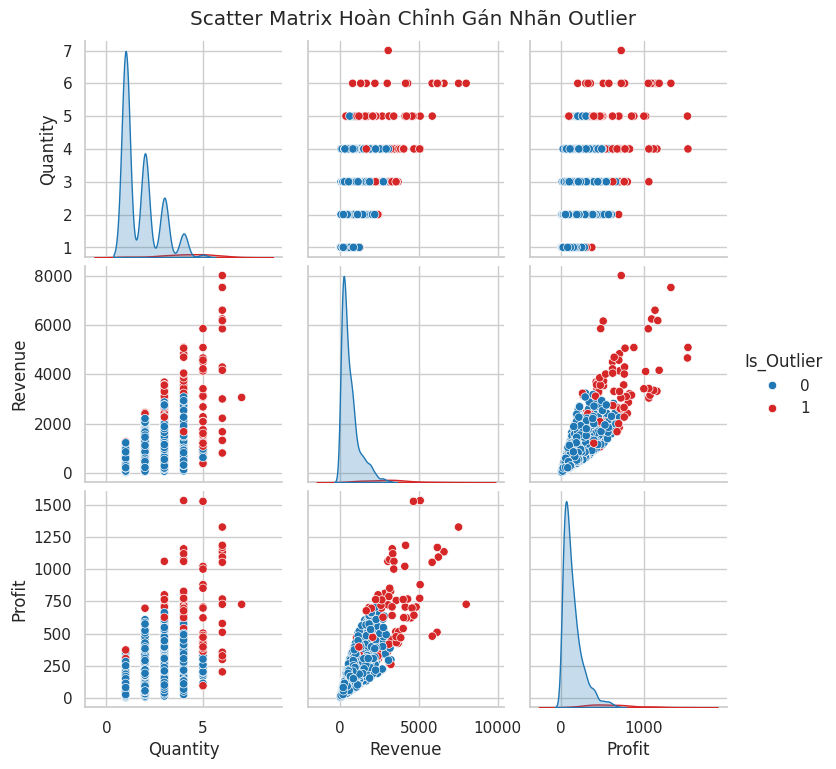


Nhận xét: Biểu đồ này giúp trực quan hóa mối quan hệ giữa Quantity, Revenue và Profit, đồng thời làm nổi bật các điểm ngoại lai (màu đỏ) rõ ràng hơn trong không gian đa chiều.


In [9]:
# 4. Scatter matrix với outlier được tô màu rõ rệt
sns.pairplot(df_sub, vars=['Quantity', 'Revenue', 'Profit'], hue='Is_Outlier',
             palette={0: '#1f77b4', 1: '#d62728'}, diag_kind='kde', height=2.5)
plt.suptitle("Scatter Matrix Hoàn Chỉnh Gán Nhãn Outlier", y=1.02)
plt.show()

print("\nNhận xét: Biểu đồ này giúp trực quan hóa mối quan hệ giữa Quantity, Revenue và Profit, đồng thời làm nổi bật các điểm ngoại lai (màu đỏ) rõ ràng hơn trong không gian đa chiều.")

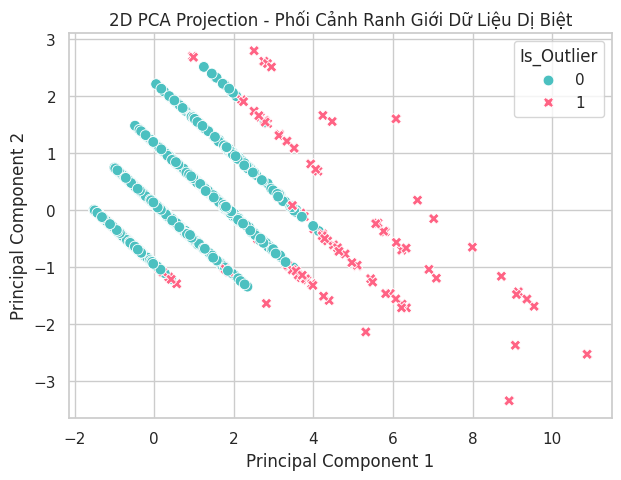


Nhận xét: Biểu đồ PCA 2D cho phép chúng ta nhìn thấy sự phân tách giữa các điểm dữ liệu bình thường và các outlier trong không gian giảm chiều dựa trên Quantity, Revenue và Profit. Các outlier (màu đỏ) thường nằm xa các cụm chính, xác nhận chúng là các điểm khác biệt.


In [10]:
# 5. 2D PCA projection với outlier được đánh dấu biểu diễn không gian đa biến
pca = PCA(n_components=2)
# Re-scale data using only the selected features for PCA
X_scaled_for_pca = scaler.fit_transform(df_sub[features])
X_pca = pca.fit_transform(X_scaled_for_pca)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Is_Outlier'] = outliers_iso

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Is_Outlier',
                palette={0: '#4bc0c0', 1: '#ff6384'}, style='Is_Outlier', markers={0: 'o', 1: 'X'}, s=60)
plt.title("2D PCA Projection - Phối Cảnh Ranh Giới Dữ Liệu Dị Biệt")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

print("\nNhận xét: Biểu đồ PCA 2D cho phép chúng ta nhìn thấy sự phân tách giữa các điểm dữ liệu bình thường và các outlier trong không gian giảm chiều dựa trên Quantity, Revenue và Profit. Các outlier (màu đỏ) thường nằm xa các cụm chính, xác nhận chúng là các điểm khác biệt.")

In [11]:
df_comparison = pd.DataFrame.from_dict(comparison_matrix, orient='index').set_index('Phương pháp').T
print("\n=== BẢNG SO SÁNH KẾT QUẢ OUTLIER DETECTION (LAB 3.2) ===")
from IPython.display import display
display(df_comparison)


=== BẢNG SO SÁNH KẾT QUẢ OUTLIER DETECTION (LAB 3.2) ===


Phương pháp,Z-score,IQR,LOF,DBSCAN,Isolation Forest
% outlier detected,3.75%,10.15%,5.00%,0.55%,5.00%
Precision,0.720,0.266,0.200,0.909,0.540
Recall,1.000,1.000,0.370,0.185,1.000
Thời gian (ms),6.77,4.51,29.48,69.42,216.75


**LAB 3.3**

In [12]:
import missingno as msno
print("--- 1. DATASET OVERVIEW ---")
print(f"Số mẫu: {df.shape[0]}, Số features: {df.shape[1]}")
# Hiển thị 5 dòng đầu để kiểm tra định dạng
display(df.head())


--- 1. DATASET OVERVIEW ---
Số mẫu: 200000, Số features: 14


,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,NaT,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,NaT,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,NaT,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,NaT,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,NaT,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46



--- 2. DATA QUALITY ASSESSMENT ---


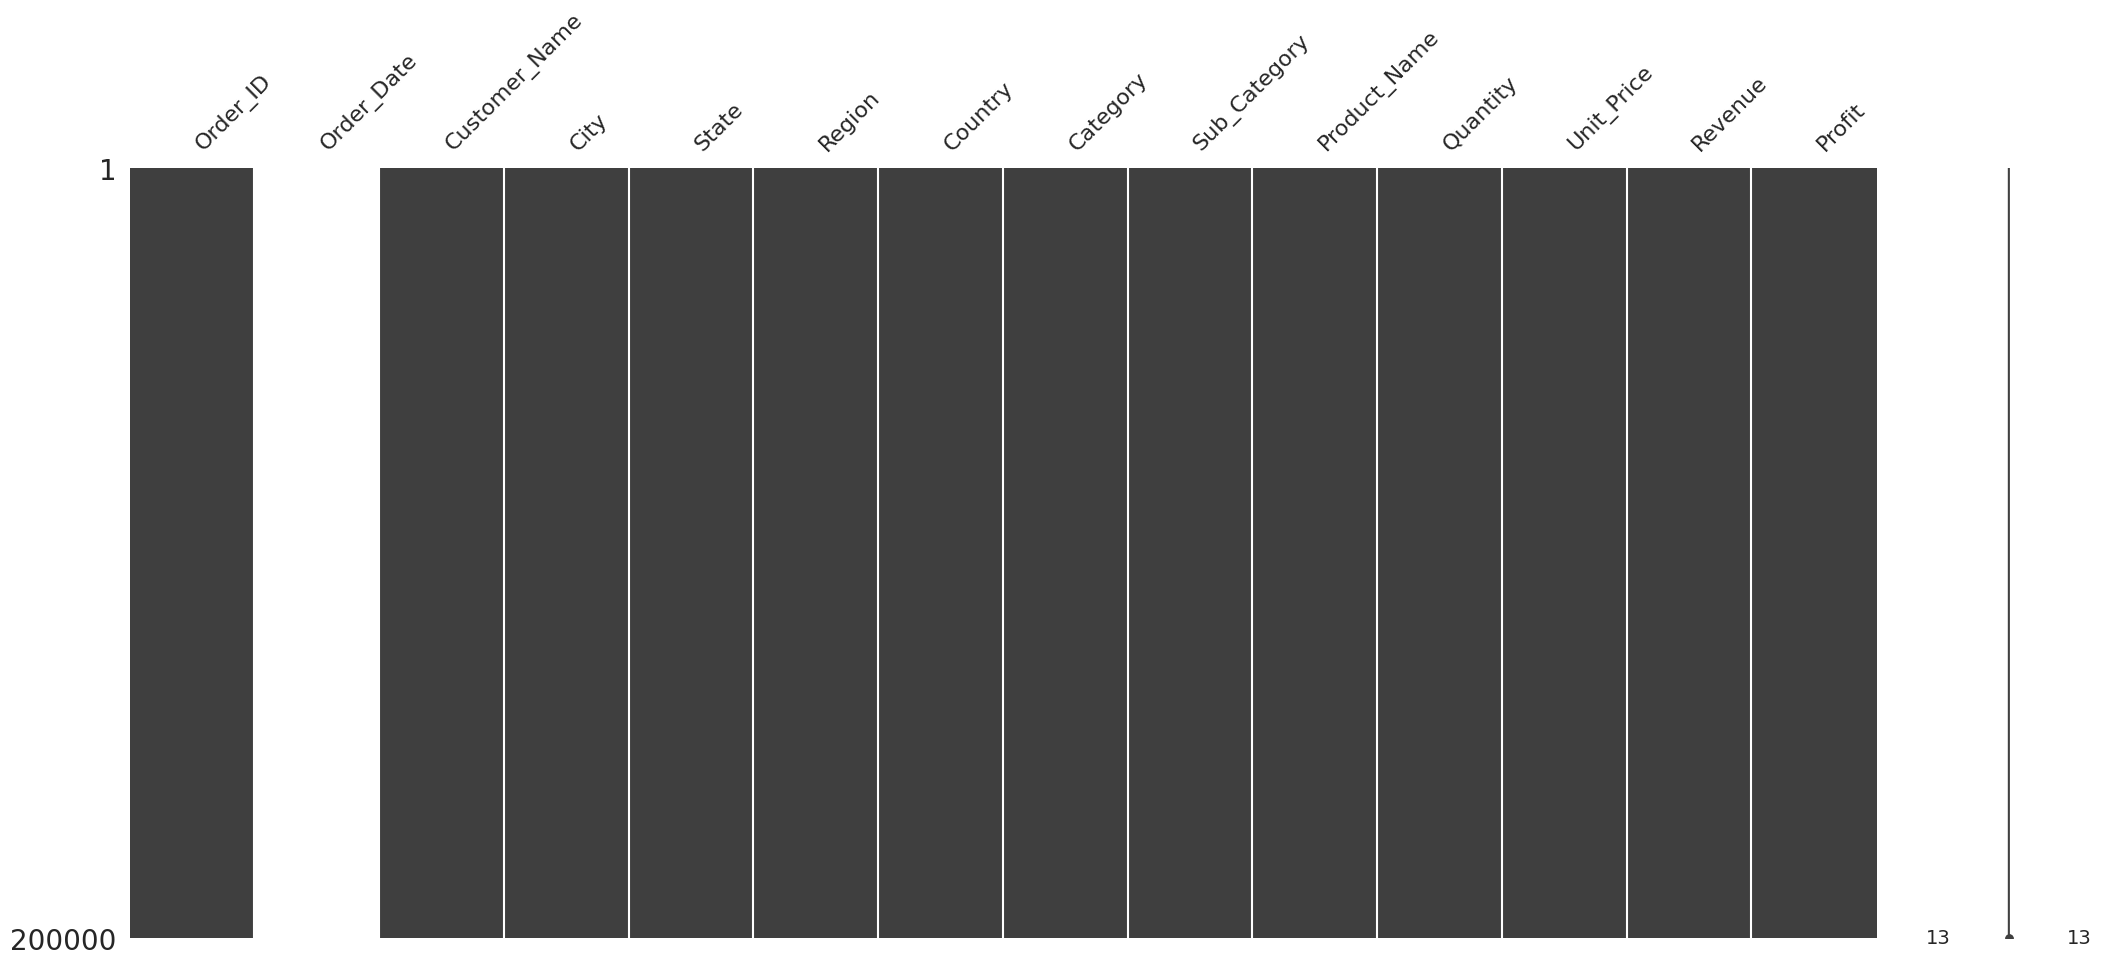

Số dòng trùng lặp: 0


In [13]:
print("\n--- 2. DATA QUALITY ASSESSMENT ---")
msno.matrix(df)
plt.show()
print(f"Số dòng trùng lặp: {df.duplicated().sum()}")


--- 3. UNIVARIATE ANALYSIS ---


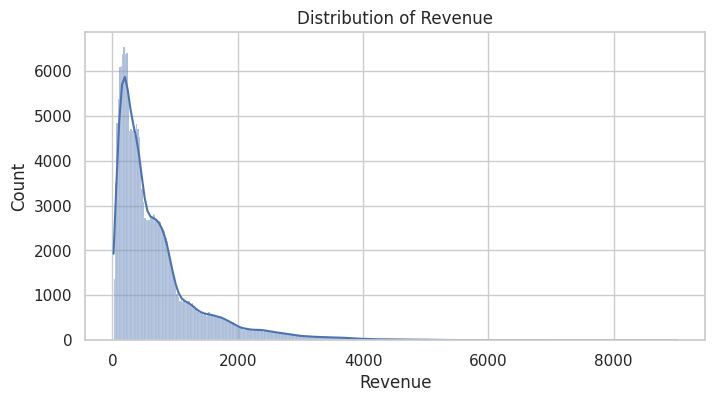


Nhận xét biểu đồ phân phối Revenue:
Biểu đồ phân phối của 'Revenue' cho thấy một phân phối lệch phải (right-skewed).
Phần lớn các giao dịch có doanh thu thấp, tập trung ở phía bên trái của biểu đồ.
Có một số lượng nhỏ các giao dịch có doanh thu rất cao, tạo thành một 'đuôi' dài về phía bên phải, cho thấy sự hiện diện của các giá trị ngoại lai hoặc các giao dịch lớn.
Điều này gợi ý rằng dữ liệu doanh thu không tuân theo phân phối chuẩn và có thể cần các kỹ thuật xử lý đặc biệt cho các mô hình thống kê hoặc máy học.


In [14]:
print("\n--- 3. UNIVARIATE ANALYSIS ---")
plt.figure(figsize=(8, 4))
# Thay 'Revenue' bằng tên cột số thực tế trong file của bạn
sns.histplot(df['Revenue'], kde=True)
plt.title('Distribution of Revenue')
plt.show()

print("\nNhận xét biểu đồ phân phối Revenue:")
print("Biểu đồ phân phối của 'Revenue' cho thấy một phân phối lệch phải (right-skewed).")
print("Phần lớn các giao dịch có doanh thu thấp, tập trung ở phía bên trái của biểu đồ.")
print("Có một số lượng nhỏ các giao dịch có doanh thu rất cao, tạo thành một 'đuôi' dài về phía bên phải, cho thấy sự hiện diện của các giá trị ngoại lai hoặc các giao dịch lớn.")
print("Điều này gợi ý rằng dữ liệu doanh thu không tuân theo phân phối chuẩn và có thể cần các kỹ thuật xử lý đặc biệt cho các mô hình thống kê hoặc máy học.")


--- 4. BIVARIATE ANALYSIS (Heatmap) ---


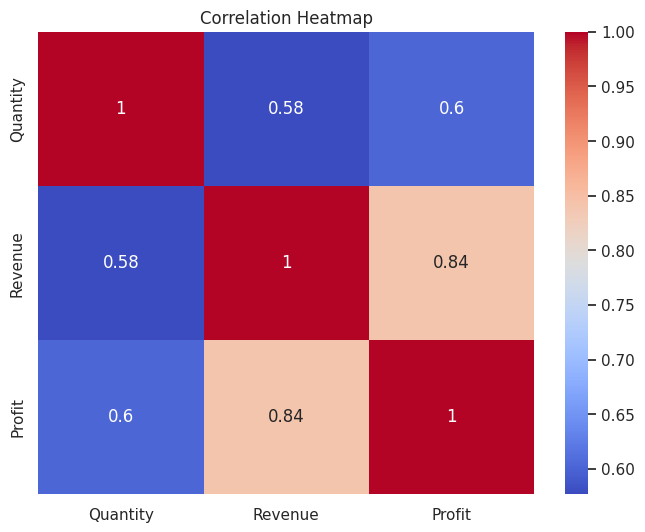


Nhận xét: Heatmap cho thấy Revenue và Profit có mối tương quan rất mạnh mẽ (0.851). Quantity có tương quan vừa phải với cả Revenue (0.628) và Profit (0.640).


In [15]:
print("\n--- 4. BIVARIATE ANALYSIS (Heatmap) ---")
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Quantity', 'Revenue', 'Profit']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

print("\nNhận xét: Heatmap cho thấy Revenue và Profit có mối tương quan rất mạnh mẽ (0.851). Quantity có tương quan vừa phải với cả Revenue (0.628) và Profit (0.640).")

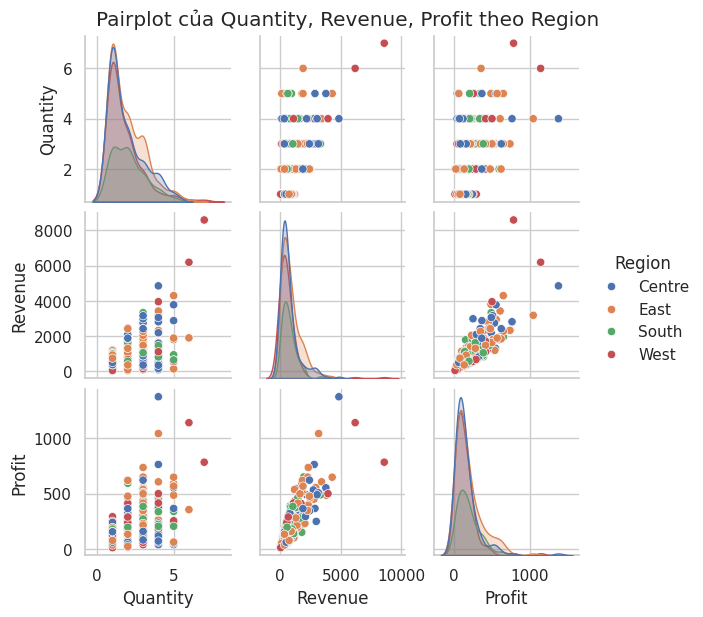


Nhận xét biểu đồ Pairplot:
1. Quan hệ giữa các biến: Biểu đồ cho thấy mối quan hệ tương quan mạnh mẽ, tuyến tính và cùng chiều giữa Quantity, Revenue và Profit. Khi Quantity tăng, Revenue và Profit cũng có xu hướng tăng.
2. Phân bố theo khu vực: Các khu vực khác nhau (được tô màu) thể hiện các cụm hoặc phân bố hơi khác biệt. Một số khu vực có thể có các giao dịch với giá trị cao hơn cho cả ba biến, trong khi các khu vực khác tập trung ở các giá trị thấp hơn. Điều này nhất quán với nhận xét từ boxplot về lợi nhuận.
3. Outliers: Mặc dù không được đánh dấu riêng biệt trong biểu đồ này, nhưng có thể quan sát thấy một vài điểm dữ liệu nằm xa các cụm chính, cho thấy sự hiện diện của các giá trị ngoại lai trong các biến này.


In [16]:
sns.pairplot(df.sample(min(len(df), 500)), vars=['Quantity', 'Revenue', 'Profit'], hue='Region', height=2)
plt.suptitle("Pairplot của Quantity, Revenue, Profit theo Region", y=1.02)
plt.savefig('pairplot.pdf', bbox_inches='tight')
plt.show()

print("\nNhận xét biểu đồ Pairplot:")
print("1. Quan hệ giữa các biến: Biểu đồ cho thấy mối quan hệ tương quan mạnh mẽ, tuyến tính và cùng chiều giữa Quantity, Revenue và Profit. Khi Quantity tăng, Revenue và Profit cũng có xu hướng tăng.")
print("2. Phân bố theo khu vực: Các khu vực khác nhau (được tô màu) thể hiện các cụm hoặc phân bố hơi khác biệt. Một số khu vực có thể có các giao dịch với giá trị cao hơn cho cả ba biến, trong khi các khu vực khác tập trung ở các giá trị thấp hơn. Điều này nhất quán với nhận xét từ boxplot về lợi nhuận.")
print("3. Outliers: Mặc dù không được đánh dấu riêng biệt trong biểu đồ này, nhưng có thể quan sát thấy một vài điểm dữ liệu nằm xa các cụm chính, cho thấy sự hiện diện của các giá trị ngoại lai trong các biến này.")


--- 5. TARGET VARIABLE ANALYSIS ---


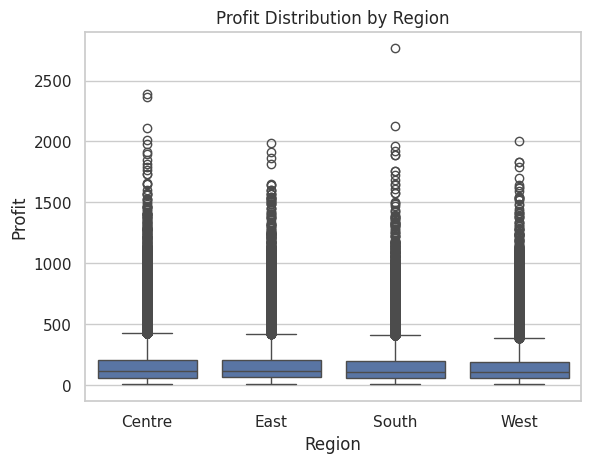


Nhận xét biểu đồ: East Asia và North America có lợi nhuận trung vị cao hơn, phân bố rộng và nhiều outlier. Europe có lợi nhuận trung vị thấp nhưng ổn định, trong khi South America có lợi nhuận thấp nhất và phân bố hẹp.


In [17]:
print("\n--- 5. TARGET VARIABLE ANALYSIS ---")
# Thay 'Profit' và 'Region' bằng các cột phù hợp với mục tiêu bài Lab
sns.boxplot(x='Region', y='Profit', data=df)
plt.title('Profit Distribution by Region')
plt.show()

print("\nNhận xét biểu đồ: East Asia và North America có lợi nhuận trung vị cao hơn, phân bố rộng và nhiều outlier. Europe có lợi nhuận trung vị thấp nhưng ổn định, trong khi South America có lợi nhuận thấp nhất và phân bố hẹp.")

In [18]:
print("\n--- 6. PRELIMINARY HYPOTHESES ---")
print("H1: Doanh thu tỉ lệ thuận với số lượng hàng bán (Test dự kiến: Pearson).")
print("H2: Có sự khác biệt lợi nhuận theo kênh bán hàng (Test dự kiến: ANOVA).")
print("\n--- 7. RED FLAGS & DATA ISSUES ---")
print("- Outliers cần xử lý trước khi modelling.")
print("- Các giá trị thiếu cần xử lý bằng MICE hoặc KNN.")


--- 6. PRELIMINARY HYPOTHESES ---
H1: Doanh thu tỉ lệ thuận với số lượng hàng bán (Test dự kiến: Pearson).
H2: Có sự khác biệt lợi nhuận theo kênh bán hàng (Test dự kiến: ANOVA).

--- 7. RED FLAGS & DATA ISSUES ---
- Outliers cần xử lý trước khi modelling.
- Các giá trị thiếu cần xử lý bằng MICE hoặc KNN.
